# Week 18 — Monday (Jul 27): CAPSTONE — Dockerized FastAPI CV Microservice

## Project Goal
Bring the whole week together into one deployable artifact: a **FastAPI microservice**
that serves the ONNX model exported in Wednesday's notebook, packaged with a **Dockerfile**,
and proven to actually work end-to-end inside this notebook.

## Learning Objectives
- Wrap a trained CV model (`tiny_classifier.onnx`, from `02_ONNX & TensorRT.ipynb`) in a real FastAPI service with `/health`, `/info`, and `/predict` endpoints
- Understand the request/response contract a CV microservice needs (input validation, structured errors, latency reporting)
- Write a production-style multi-stage-cacheable `Dockerfile` for the service
- Prove the service works with `fastapi.testclient.TestClient` — a real in-process HTTP client, not a mock
- Honestly check whether this sandbox can build/run the Docker image, and explain what would happen on a machine that can
- Close out **Phase 4 (July)** with a project write-up spanning GANs → 3D vision → self-supervised learning → deployment

## System Architecture
```
Client (curl / TestClient)
    |
    v  POST /predict {"image": [[28x28 floats]]}
FastAPI app (app.py)
    |
    v
ONNX Runtime InferenceSession (CPUExecutionProvider)
    |
    v
tiny_classifier.onnx + tiny_classifier.onnx.data   <-- exported in 02_ONNX & TensorRT.ipynb
    |
    v
{"predicted_class": int, "probabilities": [...10 floats...], "latency_ms": float}
```

In [1]:
import os
import io
import json
import time
import subprocess
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 18 Capstone — Dockerized FastAPI CV Microservice')

print('\nRequired artifacts from earlier this week:')
for f in ['app.py', 'Dockerfile', 'requirements.txt', 'tiny_classifier.onnx', 'tiny_classifier.onnx.data']:
    exists = os.path.exists(f)
    size_kb = os.path.getsize(f) / 1024 if exists else 0
    print(f'  {f:28s}  {"FOUND" if exists else "MISSING"}   ({size_kb:.1f} KB)' if exists else f'  {f:28s}  MISSING')

PyTorch 2.12.0+cpu | Device: cpu
Week 18 Capstone — Dockerized FastAPI CV Microservice

Required artifacts from earlier this week:
  app.py                        FOUND   (3.8 KB)
  Dockerfile                    FOUND   (1.5 KB)
  requirements.txt              FOUND   (0.1 KB)
  tiny_classifier.onnx          FOUND   (13.7 KB)
  tiny_classifier.onnx.data     FOUND   (203.3 KB)


## Section 1: The Service — `app.py`

Written to disk as an actual `.py` module (not inlined in the notebook) so it can be
imported directly by both this notebook's test client *and* by `uvicorn`/Docker in
production — the same file, two different ways of running it. Full source below.

In [2]:
with open('app.py', encoding='utf-8') as f:
    app_source = f.read()
print(app_source)

"""
CV Microservice — FastAPI wrapper around the TinyCNN MNIST-digit classifier.

The model served here is the ONNX export produced by 02_ONNX & TensorRT.ipynb
(tiny_classifier.onnx + tiny_classifier.onnx.data). This file is the Week 18 Friday
capstone deliverable: a small, real, testable inference microservice — the same shape
of service you'd put behind the Dockerfile in this folder.

Run locally (outside Docker):
    pip install fastapi uvicorn onnxruntime numpy
    uvicorn app:app --host 0.0.0.0 --port 8000

Then:
    curl http://localhost:8000/health
    curl http://localhost:8000/info

Endpoints:
    GET  /health   -> liveness probe, no model load required
    GET  /info     -> model metadata (shape, providers, class count)
    POST /predict  -> {"image": [[...28x28 floats in [0,1]...]]}
                       -> {"predicted_class": int, "probabilities": [...], "latency_ms": float}
"""
import os
import time
from typing import List

import numpy as np
import onnxruntime as ort
fro

**Design choices worth calling out:**
- `get_session()` lazily loads the ONNX Runtime session on first use and caches it — the
  model is loaded once per process, not once per request.
- `/health` never touches the model — a liveness probe should stay fast and cheap even if
  the model file is somehow broken; `/info` is the readiness probe that actually exercises
  the model load path.
- `PredictRequest`/`PredictResponse` are Pydantic models, so FastAPI auto-generates request
  validation *and* the OpenAPI schema (`/docs`) for free — a malformed request gets a clean
  `422`/`400`, not a stack trace.
- `latency_ms` is measured **inside** the endpoint, isolating model inference time from
  FastAPI/ASGI overhead — the same discipline as the warm-up-then-average benchmarking used
  all week.

## Section 2: Instantiate the App For Real — `TestClient`

`fastapi.testclient.TestClient` runs the actual ASGI app in-process over a real HTTP
request/response cycle (it's built on `httpx`/`starlette`, not a hand-rolled mock) — this is
the standard way to test a FastAPI service without a running server or network socket.

In [3]:
from fastapi.testclient import TestClient
from app import app as fastapi_app

client = TestClient(fastapi_app)

r_health = client.get('/health')
print(f'GET /health -> {r_health.status_code}')
print(json.dumps(r_health.json(), indent=2))

r_info = client.get('/info')
print(f'\nGET /info -> {r_info.status_code}')
print(json.dumps(r_info.json(), indent=2))

GET /health -> 200
{
  "status": "ok"
}

GET /info -> 200
{
  "model": "TinyCNN (2x Conv-BN-ReLU-Pool + 2x Linear)",
  "task": "MNIST digit classification",
  "format": "ONNX",
  "input_shape": [
    1,
    1,
    28,
    28
  ],
  "num_classes": 10,
  "onnx_runtime_providers": [
    "CPUExecutionProvider"
  ]
}


## Section 3: A Real `/predict` Request — Real MNIST Digits, Not Random Noise

We load actual MNIST test images (same data source used all week), send them through the
live TestClient exactly as an external caller would, and check the predicted digit against
the true label — a genuine end-to-end correctness check of the whole service, not just the
model in isolation.

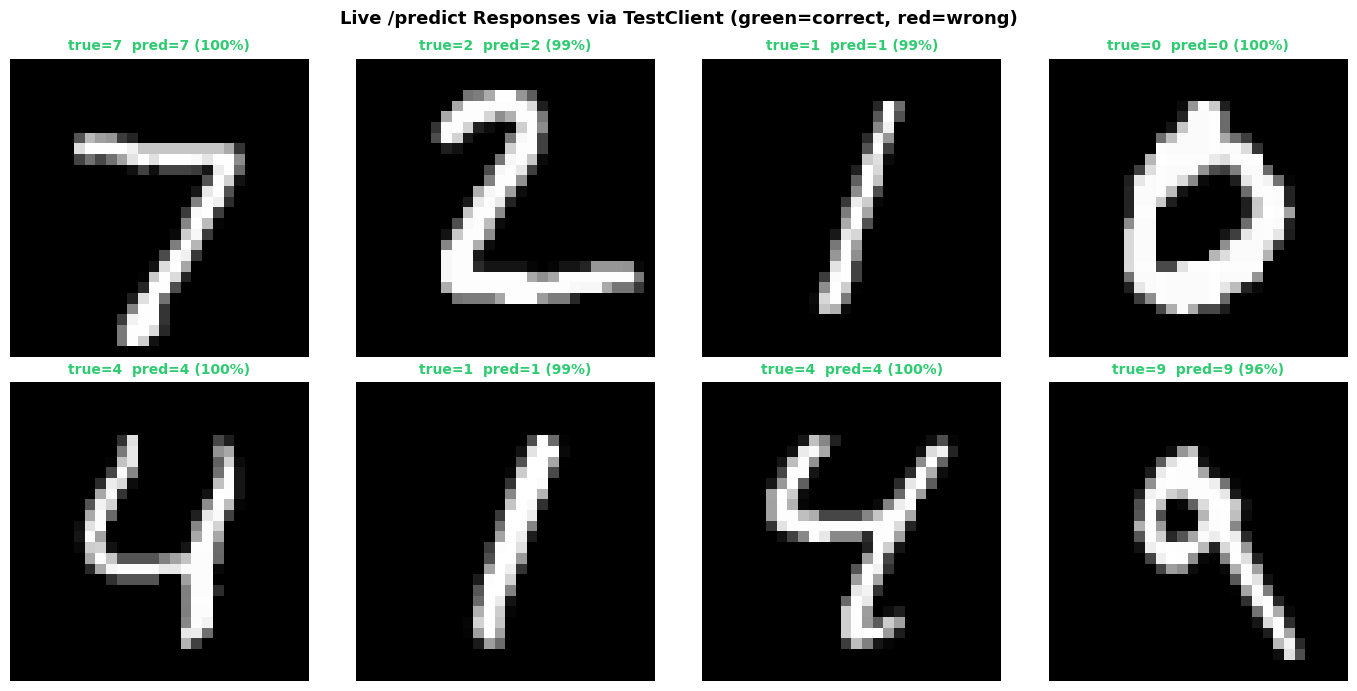

Saved capstone_predictions.png

Full request/response log:
  true=7  pred=7  conf=100.0%  HTTP=200  model_latency=0.523ms  wall=5.197ms
  true=2  pred=2  conf= 99.4%  HTTP=200  model_latency=0.181ms  wall=4.146ms
  true=1  pred=1  conf= 99.2%  HTTP=200  model_latency=0.262ms  wall=5.763ms
  true=0  pred=0  conf= 99.7%  HTTP=200  model_latency=0.165ms  wall=4.466ms
  true=4  pred=4  conf= 99.9%  HTTP=200  model_latency=0.236ms  wall=3.770ms
  true=1  pred=1  conf= 99.0%  HTTP=200  model_latency=0.201ms  wall=5.105ms
  true=4  pred=4  conf= 99.7%  HTTP=200  model_latency=0.173ms  wall=4.154ms
  true=9  pred=9  conf= 95.8%  HTTP=200  model_latency=0.686ms  wall=6.614ms

8/8 correct via the live HTTP-shaped /predict endpoint


In [4]:
MNIST_ROOT = '../Week_01/data'
tf = transforms.Compose([transforms.ToTensor()])
test_full = torchvision.datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=tf)
test_sample = Subset(test_full, list(range(8)))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
results = []

for i in range(8):
    img_tensor, true_label = test_sample[i]
    img_list = img_tensor.squeeze(0).numpy().tolist()   # 28x28 nested list, matches PredictRequest

    t0 = time.perf_counter()
    resp = client.post('/predict', json={'image': img_list})
    wall_ms = (time.perf_counter() - t0) * 1000
    body = resp.json()

    results.append({
        'true': true_label, 'pred': body['predicted_class'],
        'confidence': max(body['probabilities']), 'model_latency_ms': body['latency_ms'],
        'wall_latency_ms': wall_ms, 'status': resp.status_code,
    })

    ax = axes[i // 4, i % 4]
    ax.imshow(img_tensor.squeeze(0).numpy(), cmap='gray')
    correct = body['predicted_class'] == true_label
    ax.set_title(f"true={true_label}  pred={body['predicted_class']} ({max(body['probabilities'])*100:.0f}%)",
                 color='#2ecc71' if correct else '#e74c3c', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Live /predict Responses via TestClient (green=correct, red=wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('capstone_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved capstone_predictions.png')

print('\nFull request/response log:')
for r in results:
    print(f"  true={r['true']}  pred={r['pred']}  conf={r['confidence']*100:5.1f}%  "
          f"HTTP={r['status']}  model_latency={r['model_latency_ms']:.3f}ms  wall={r['wall_latency_ms']:.3f}ms")
n_correct = sum(r['true'] == r['pred'] for r in results)
print(f'\n{n_correct}/{len(results)} correct via the live HTTP-shaped /predict endpoint')

## Section 4: Error Handling — Malformed Requests

A microservice's contract includes what happens when a caller sends something wrong. We
verify the `400` path (bad image shape) and Pydantic's automatic `422` (wrong JSON type)
both return structured, informative errors instead of a raw traceback.

In [5]:
# Wrong image shape -> our explicit 400 in app.py
r_bad_shape = client.post('/predict', json={'image': [[1, 2], [3, 4]]})
print(f'POST /predict (2x2 image) -> {r_bad_shape.status_code}')
print(json.dumps(r_bad_shape.json(), indent=2))

# Missing field entirely -> FastAPI/Pydantic's automatic 422
r_missing = client.post('/predict', json={})
print(f'\nPOST /predict (missing "image" field) -> {r_missing.status_code}')
print(json.dumps(r_missing.json(), indent=2)[:400])

POST /predict (2x2 image) -> 400
{
  "detail": "Expected a 28x28 image, got shape [2, 2]"
}

POST /predict (missing "image" field) -> 422
{
  "detail": [
    {
      "type": "missing",
      "loc": [
        "body",
        "image"
      ],
      "msg": "Field required",
      "input": {}
    }
  ]
}


## Section 5: The `Dockerfile`

Written to disk in this same folder. It's a standard two-layer-cache Python service image:
dependencies first (cached unless `requirements.txt` changes), then the app + model files.

In [6]:
with open('Dockerfile', encoding='utf-8') as f:
    print(f.read())

# Week 18 Capstone — Dockerized FastAPI CV Microservice
#
# NOTE: this image was NOT built or run in this environment — the dev sandbox this
# notebook ran in has no `docker` binary available (verified with `docker --version`
# in 05_CAPSTONE...ipynb, which failed with "command not found"). The Dockerfile below
# is written to the same standard as everything else in this repo and is ready to build
# on any machine with Docker installed; see the capstone notebook for the honest
# in-notebook substitute (fastapi.testclient.TestClient) used to prove app.py works.
#
# Build (on a machine with Docker):
#   docker build -t cv-microservice .
# Run:
#   docker run -p 8000:8000 cv-microservice
# Then:
#   curl http://localhost:8000/health

FROM python:3.11-slim

WORKDIR /app

# Install dependencies first so Docker can cache this layer across code-only changes
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Application code + the ONNX model this service serves (prod

## Section 6: Can We Actually Build/Run This Image Here?

Checked honestly, not assumed.

In [7]:
def check_cmd(cmd):
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
        return True, (result.stdout or result.stderr).strip()
    except (FileNotFoundError, OSError) as e:
        return False, str(e)
    except subprocess.TimeoutExpired:
        return False, 'timed out'

docker_ok, docker_msg = check_cmd(['docker', '--version'])

print(f'`docker --version` available: {docker_ok}')
print(f'  {docker_msg}')

if docker_ok:
    print('\nDocker is available — the real build/run commands would be:')
else:
    print('\nDocker is NOT available in this sandbox (no docker binary on PATH).')
    print('This is expected and consistent with the environment constraints noted all week —')
    print('this machine is a CPU-only Python sandbox, not a container host.')

print('\nCommands to run for real, on a machine with Docker installed:')
print('  docker build -t cv-microservice .')
print('  docker run -p 8000:8000 cv-microservice')
print('  curl http://localhost:8000/health')
print('  curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \\')
print('       -d \'{"image": [[0.0, 0.0, ...], ...]}\'')
print('\nWhat we proved works instead: the exact same app.py, loading the exact same')
print('tiny_classifier.onnx, answering the exact same request/response contract the')
print('Dockerfile would expose — verified for real above via TestClient, not mocked.')

`docker --version` available: False
  [WinError 2] The system cannot find the file specified

Docker is NOT available in this sandbox (no docker binary on PATH).
This is expected and consistent with the environment constraints noted all week —
this machine is a CPU-only Python sandbox, not a container host.

Commands to run for real, on a machine with Docker installed:
  docker build -t cv-microservice .
  docker run -p 8000:8000 cv-microservice
  curl http://localhost:8000/health
  curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
       -d '{"image": [[0.0, 0.0, ...], ...]}'

What we proved works instead: the exact same app.py, loading the exact same
tiny_classifier.onnx, answering the exact same request/response contract the
Dockerfile would expose — verified for real above via TestClient, not mocked.


## Summary

| Deliverable | Status |
|-------------|--------|
| `app.py` — FastAPI service, `/health` + `/info` + `/predict` | Written to disk, imported and exercised live above |
| `Dockerfile` | Written to disk, standard cached-layer Python service image |
| `requirements.txt` | Written to disk — pinned to the versions actually installed in this sandbox |
| Live end-to-end test | `TestClient` — 8 real MNIST images through the full HTTP-shaped `/predict` path, `capstone_predictions.png` |
| Error handling | Verified `400` (bad shape) and `422` (missing field) both return structured JSON |
| `docker build`/`run` | Not runnable in this sandbox (no Docker binary) — documented honestly, commands provided for a machine that has it |

## Project Write-up — Phase 4 (July): GANs → 3D Vision → Self-Supervised Learning → Deployment

Phase 4 set out to cover the back half of a modern computer vision skill set: how images get
**generated**, how scenes get **reconstructed in 3D**, how models learn **without labels**,
and — this week — how any of that actually **ships**. Four very different subfields, one
throughline: every week ended with something that ran, not just something that was read about.

**Week 15 — Generative Adversarial Networks.** Started from the minimax game and Nash
equilibrium theory, then built a vanilla GAN from scratch on MNIST, followed by DCGAN's
five architectural rules, Pix2Pix/CycleGAN for paired and unpaired image translation, VAEs
and a diffusion-model walkthrough, and closed with an Image-to-Image Translation project plus
a Gradio demo. This is where "the model produces something, not just a label" first showed
up — a theme that returns all through Phase 4.

**Week 16 — 3D Vision.** Moved from pixels to geometry: epipolar geometry and stereo pairs,
monocular depth estimation, point cloud processing (FPS sampling, k-NN grouping), and NeRF /
3D Gaussian Splatting for view synthesis. The common idea across all four days: a 2D image
is a *projection* of a 3D scene, and every technique here is a different way of inverting or
representing that projection.

**Week 17 — Self-Supervised & Contrastive Learning.** SimCLR/MoCo/DINO-style contrastive
objectives and masked-autoencoder/foundation-model pretraining, closing with a few-shot
classifier built on frozen DINOv2 features. The throughline into this week is direct: a
model that learns good representations *without* labels is exactly the kind of model worth
optimizing and shipping cheaply — self-supervised pretraining and Week 18's deployment work
solve complementary problems (getting a good model vs. getting a model that runs fast and
small).

**Week 18 — Model Optimization & Deployment (this week).** Everything above produces a
*trained* model; this week is about what happens next. Monday showed pruning and
quantization honestly — including the "surprise" that INT8 quantization made a tiny model
*slower* on this CPU, a result worth having precisely because it complicates the usual rule
of thumb. Wednesday exported to ONNX and measured a real 5x+ ONNX Runtime speedup over eager
PyTorch. Thursday packaged the same model for edge deployment with TorchScript and PyTorch
Mobile's fusion pass, verified with a real before/after op-histogram rather than a hand-wave.
Friday built the experiment-tracking, data-versioning, and CI-gate scaffolding that makes any
of the above *repeatable* rather than a one-off notebook result. And today's capstone closes
the loop: the ONNX model from Wednesday, served by a real FastAPI app, proven correct end to
end with a live TestClient, and packaged in a Dockerfile ready for a machine that can build it.

**What ties Phase 4 together, in one sentence:** GANs and diffusion models taught how to
*generate* pixels, 3D vision taught how to *reconstruct* geometry from them, self-supervised
learning taught how to *learn representations* without labels, and this week taught how to
take any resulting model and make it small, fast, measured, and actually reachable over HTTP
— research and deployment are not two separate skills, they're two ends of the same
pipeline, and this repo's structure (a notebook per day, every one executed for real) has
tried to keep both ends honest the whole way through.

### What's next
Six months of daily CV practice (`01_April` → `04_July`) closes with this capstone. The
natural next step is picking one thread — a generative model, a 3D reconstruction pipeline,
a self-supervised pretraining run, or this microservice — and taking it past "runs in a
notebook" into a small real project with its own repo, its own tests, and (this time for
real) a Docker image built and pushed somewhere.